### Logistic Regression-Diabetes Model

In [1]:
import numpy as  np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score, precision_score, recall_score 
from sklearn.metrics import roc_auc_score, roc_curve, multilabel_confusion_matrix

import warnings
warnings.filterwarnings('ignore')

### 1. Problem Statement

In [ ]:
To Predict patient is having diabetes or not by using required parameteres

'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI',
'DiabetesPedigreeFunction', 'Age'

In [11]:
!python --version

Python 3.11.7


### 2. Data Gathering

In [2]:
df_diab = pd.read_csv('diabetes.csv')
df_diab.head()

,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,148,50,35,0,33.6,0.627,50,1
1,85,66,29,0,26.6,0.351,31,0
2,183,64,0,0,23.3,0.672,52,1
3,150,66,23,94,28.1,0.167,21,0
4,150,40,35,168,43.1,2.288,33,1


### EDA

In [3]:
df_diab.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Glucose                   768 non-null    int64  
 1   BloodPressure             768 non-null    int64  
 2   SkinThickness             768 non-null    int64  
 3   Insulin                   768 non-null    int64  
 4   BMI                       768 non-null    float64
 5   DiabetesPedigreeFunction  768 non-null    float64
 6   Age                       768 non-null    int64  
 7   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 48.1 KB


In [4]:
df_diab.describe()

,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,121.117188,69.076823,20.536458,79.799479,31.992578,0.471876,33.243490,0.348958
std,31.805091,19.367794,15.952218,115.244002,7.884160,0.331329,11.758182,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,142.000000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [5]:
df_diab.isnull().sum()

Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [6]:
df_diab.duplicated().sum()

0

##### 3.1 Glucose

<Axes: xlabel='Glucose', ylabel='Density'>

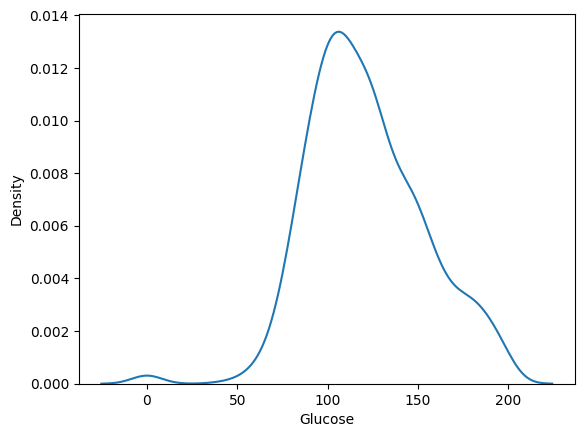

In [7]:
sns.kdeplot(df_diab['Glucose'])

<Axes: ylabel='Glucose'>

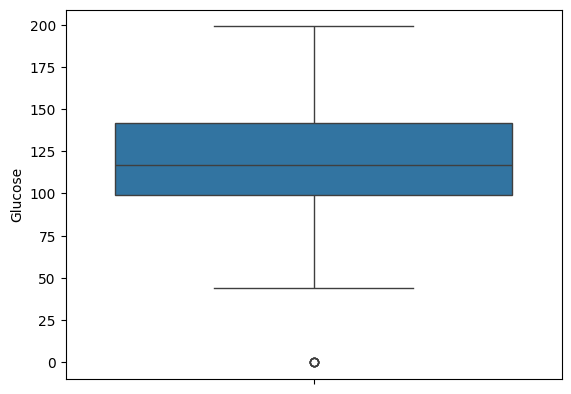

In [8]:
sns.boxplot(df_diab['Glucose'])

<Axes: >

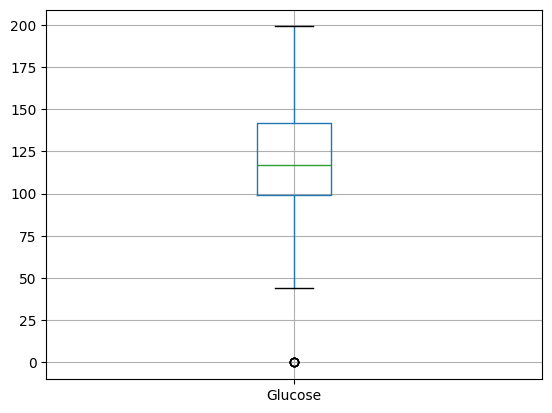

In [9]:
df_diab[['Glucose']].boxplot()

In [10]:
df_diab['Glucose'] = np.where(df_diab['Glucose'] < 25, df_diab['Glucose'].median(), df_diab['Glucose'])

##### 3.2 BloodPressure

<Axes: xlabel='BloodPressure', ylabel='Density'>

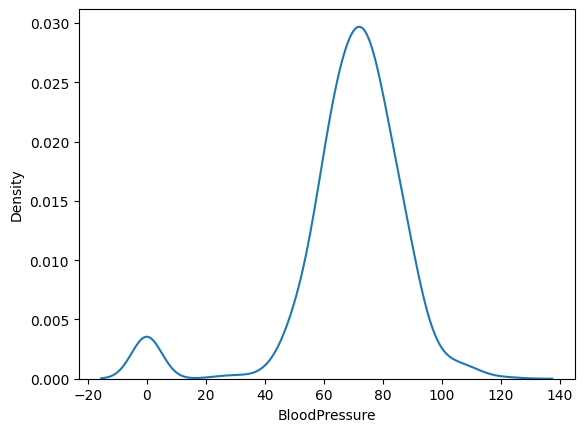

In [11]:
sns.kdeplot(df_diab['BloodPressure'])

<Axes: ylabel='BloodPressure'>

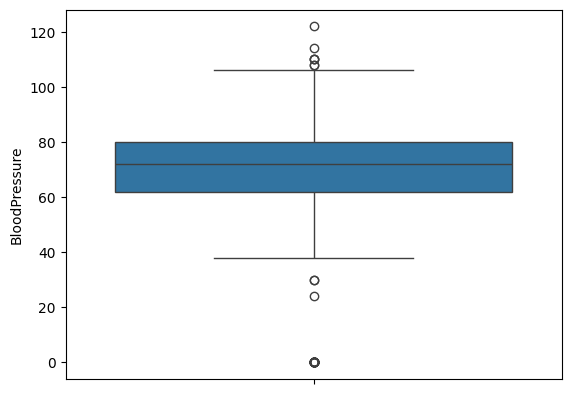

In [12]:
sns.boxplot(df_diab['BloodPressure'])

<Axes: >

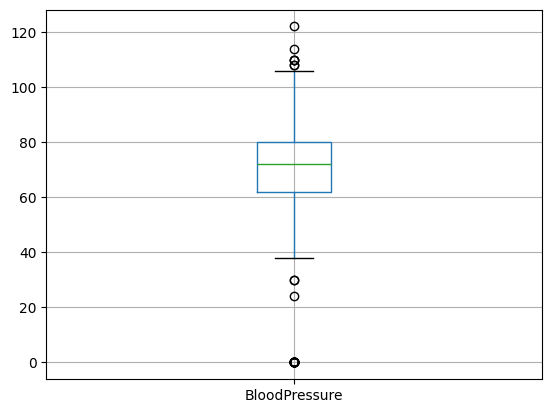

In [13]:
df_diab[['BloodPressure']].boxplot()

In [14]:
df_diab[~df_diab['BloodPressure'].between(35,105)].shape

(48, 8)

In [15]:
df_diab['BloodPressure'] = np.where(~df_diab['BloodPressure'].between(35,105), df_diab['BloodPressure'].median(),
                                   df_diab['BloodPressure'])

##### 3.3 SkinThickness

<Axes: xlabel='SkinThickness', ylabel='Density'>

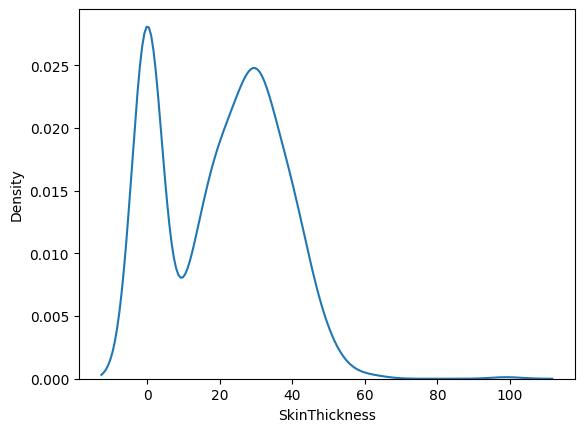

In [16]:
sns.kdeplot(df_diab['SkinThickness'])

<Axes: ylabel='SkinThickness'>

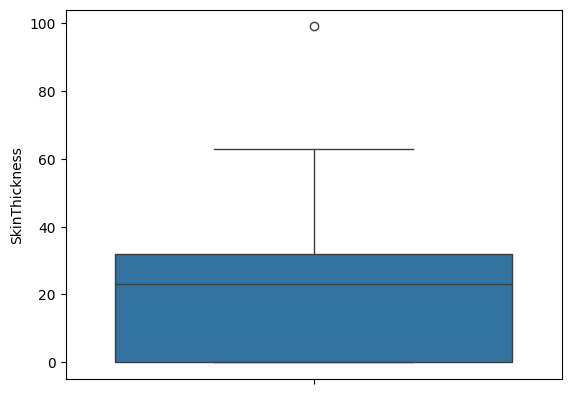

In [17]:
sns.boxplot(df_diab['SkinThickness'])

In [18]:
df_diab['SkinThickness'] = np.where(df_diab['SkinThickness'] > 65, df_diab['SkinThickness'].median(), df_diab['SkinThickness'])

##### 3.4 Insulin

<Axes: xlabel='Insulin', ylabel='Density'>

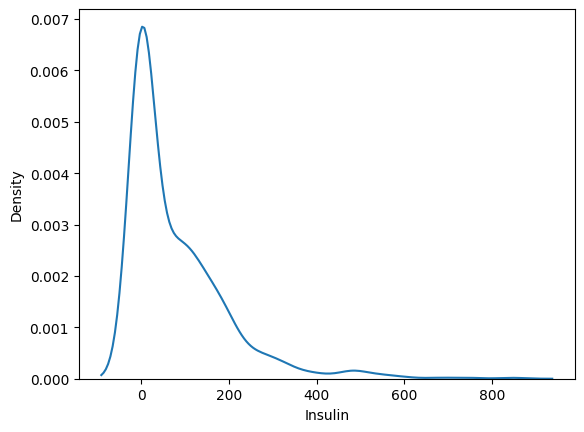

In [19]:
sns.kdeplot(df_diab['Insulin'])

<Axes: ylabel='Insulin'>

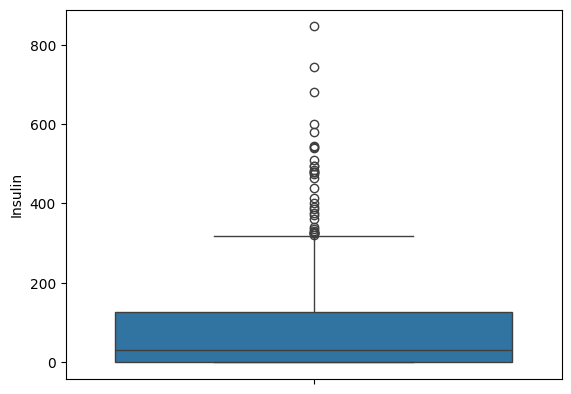

In [20]:
sns.boxplot(df_diab['Insulin'])

<Axes: >

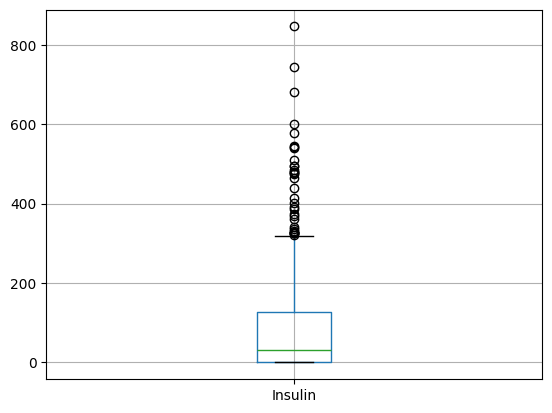

In [21]:
df_diab[['Insulin']].boxplot()

In [22]:
df_diab['Insulin'] = np.where(df_diab['Insulin'] > 325, df_diab['Insulin'].median(), df_diab['Insulin'])

##### 3.5 BMI

<Axes: xlabel='BMI', ylabel='Density'>

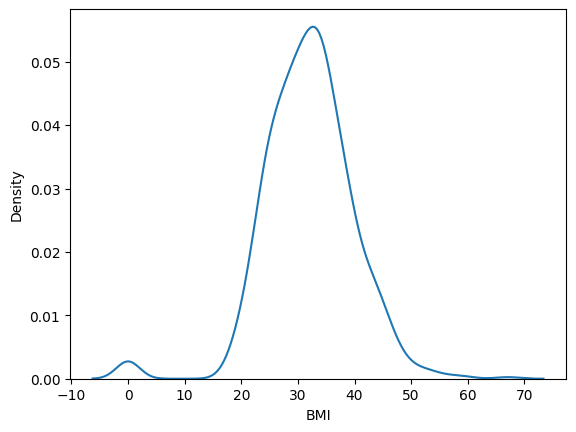

In [23]:
sns.kdeplot(df_diab['BMI'])

<Axes: >

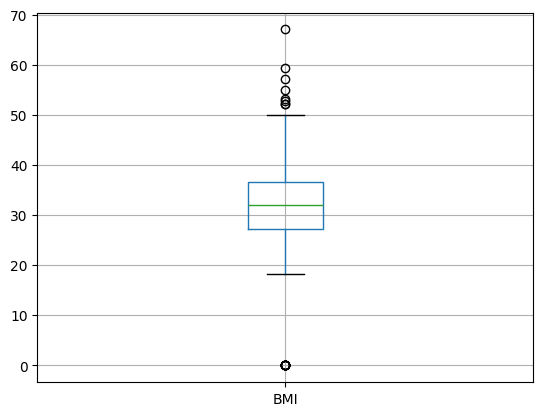

In [24]:
df_diab[['BMI']].boxplot()

In [25]:
df_diab['BMI'] = np.where(~df_diab['BMI'].between(15,50), df_diab['BMI'].median(),df_diab['BMI'])

##### 3.6 DiabetesPedigreeFunction

<Axes: xlabel='DiabetesPedigreeFunction', ylabel='Density'>

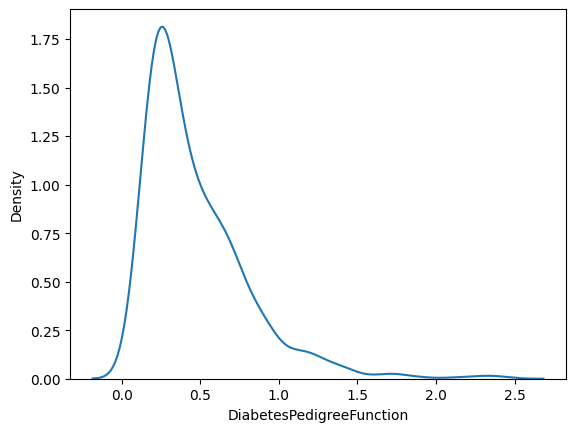

In [26]:
sns.kdeplot(df_diab['DiabetesPedigreeFunction'])

<Axes: >

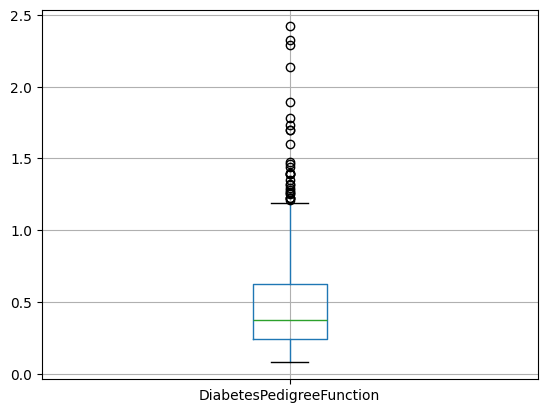

In [27]:
df_diab[['DiabetesPedigreeFunction']].boxplot()

In [28]:
df_diab['DiabetesPedigreeFunction'] = np.where(df_diab['DiabetesPedigreeFunction'] >= 1.2, 
                                               df_diab['DiabetesPedigreeFunction'].median(),
                                               df_diab['DiabetesPedigreeFunction'])

##### 3.7 Age

<Axes: xlabel='Age', ylabel='Density'>

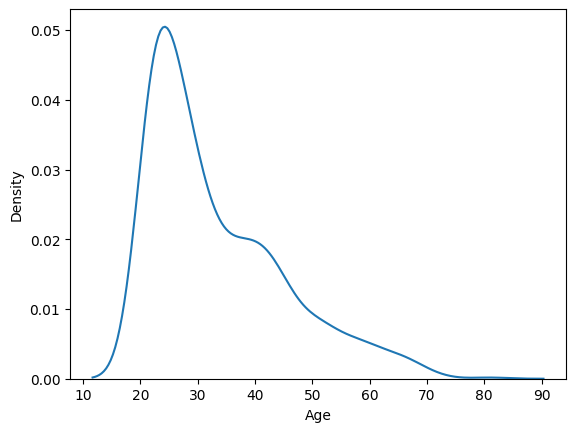

In [29]:
sns.kdeplot(df_diab['Age'])

<Axes: >

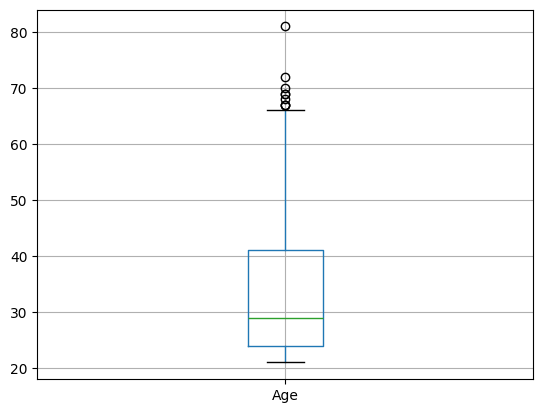

In [30]:
df_diab[['Age']].boxplot()

In [31]:
df_diab['Age'] = np.where(df_diab['Age'] >= 67, df_diab['Age'].median(),df_diab['Age'])

##### 3.8 Outcome

In [32]:
df_diab['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [33]:
df_diab['Outcome'].value_counts(normalize=True)

Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64

<Axes: ylabel='count'>

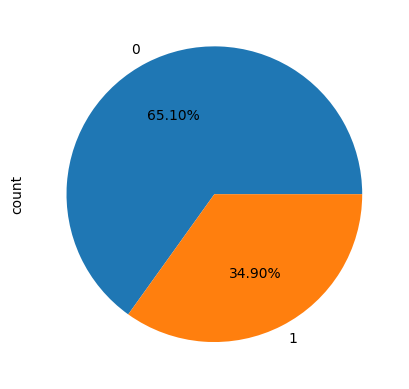

In [34]:
df_diab['Outcome'].value_counts().plot(kind = 'pie', autopct = '%1.2f%%')

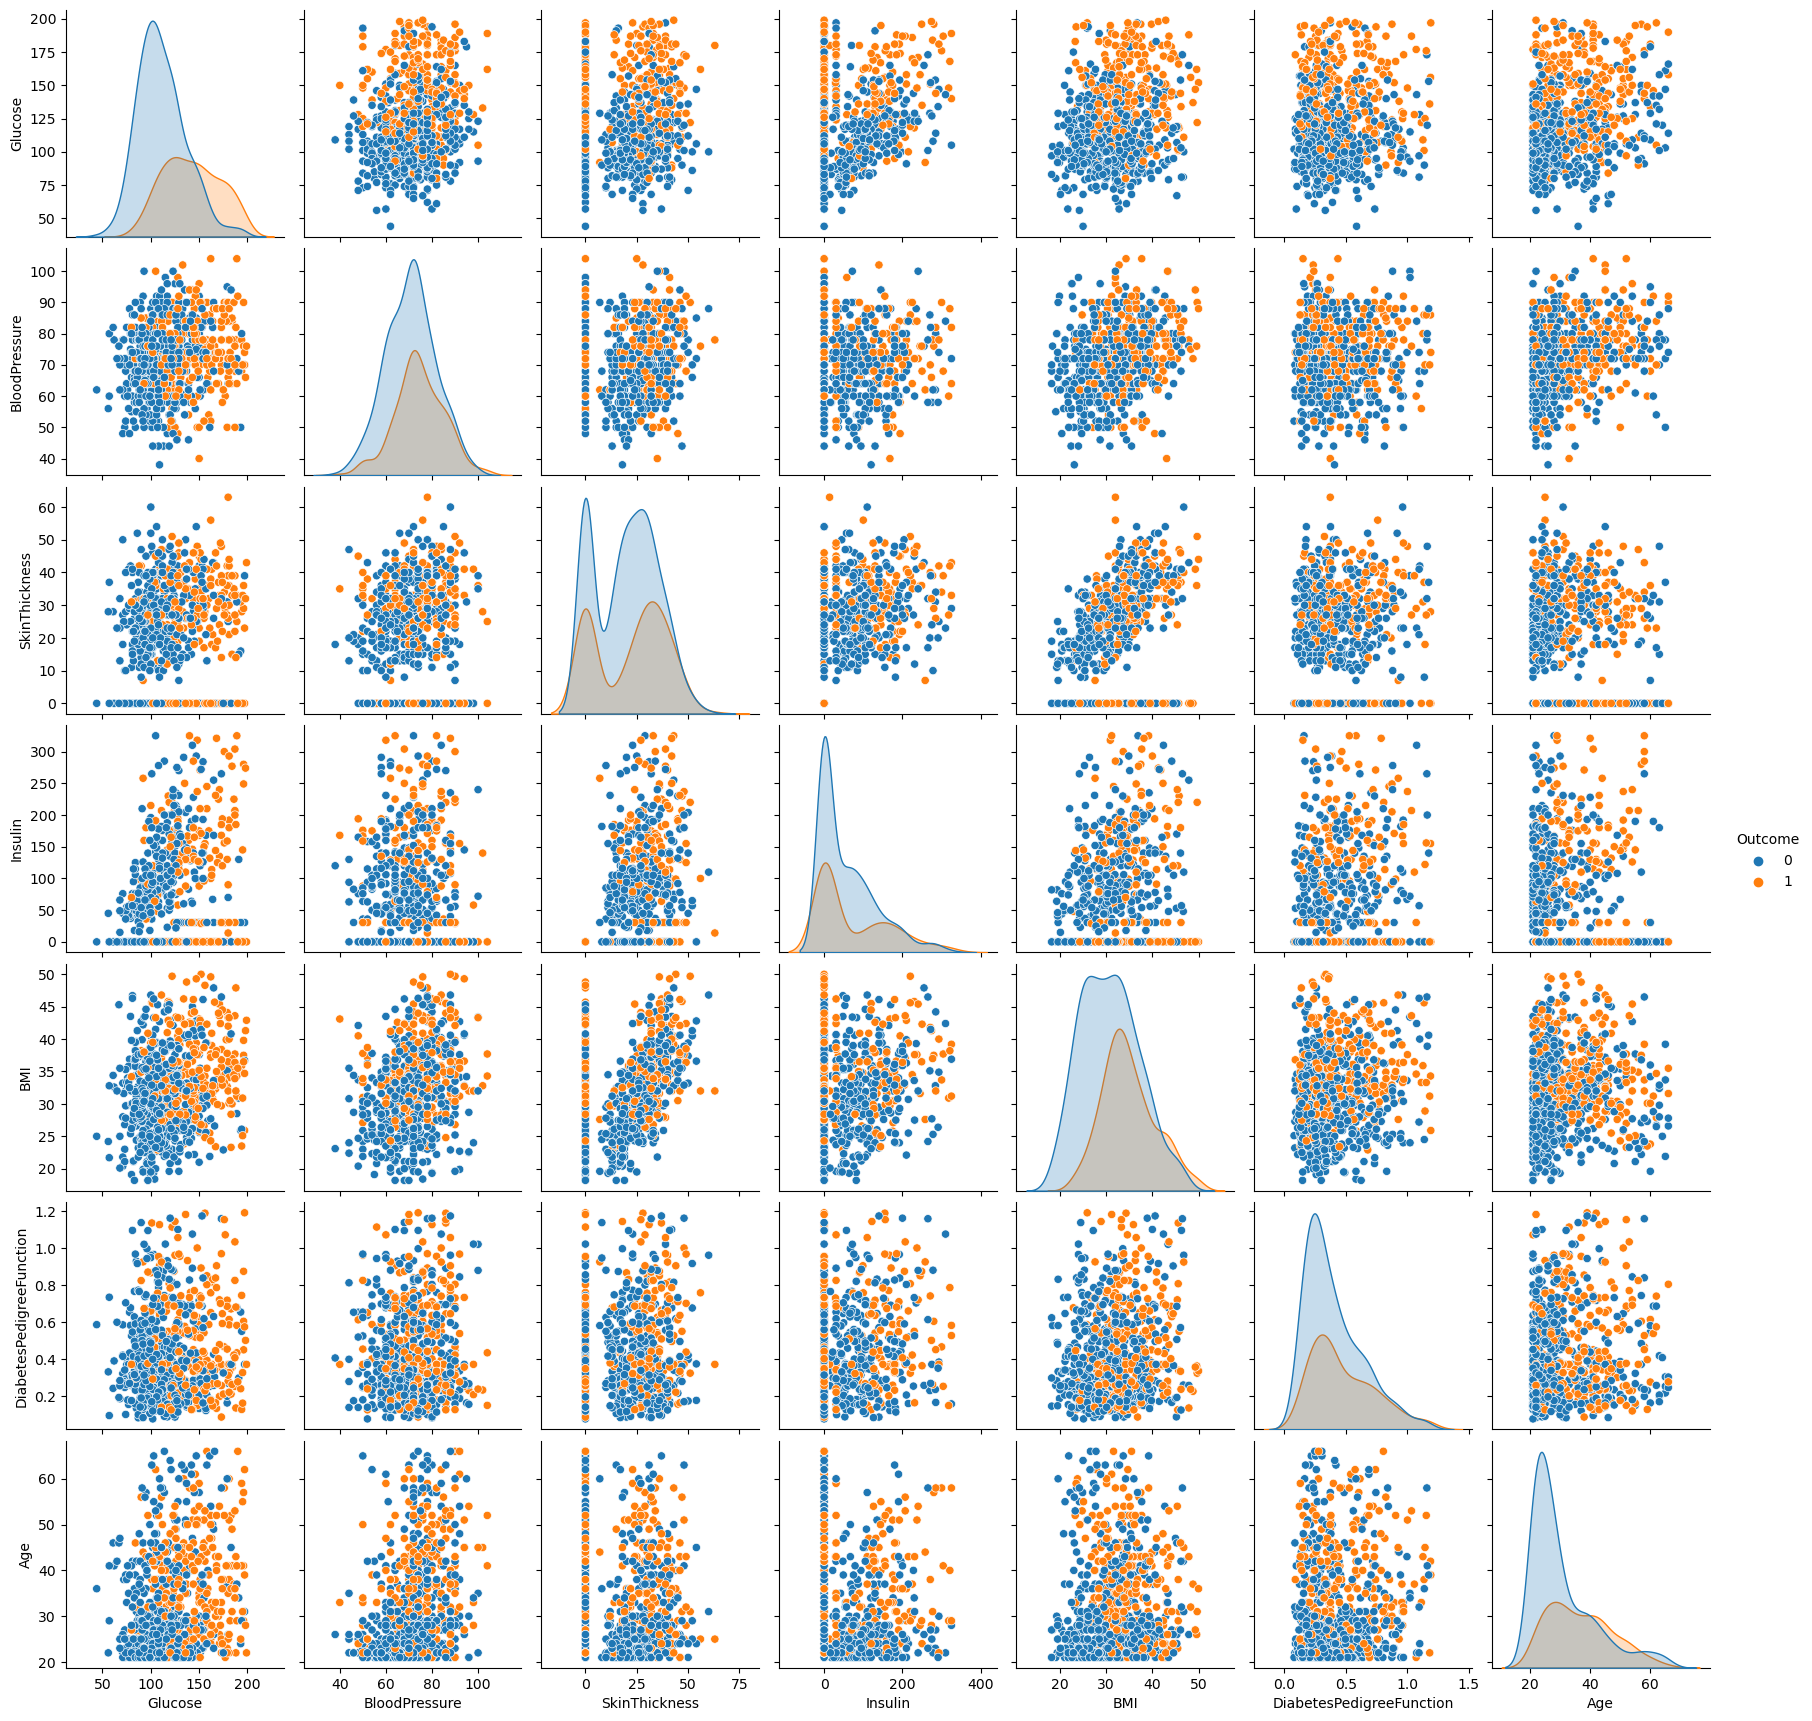

In [36]:
sns.pairplot(df_diab, hue = 'Outcome')

### 4. Feature Engineering

### 5. Feature Selection

#### 5.1 VIF

In [35]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [36]:
x = df_diab.drop('Outcome', axis =1)
x

,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,148.0,50.0,35.0,0.0,33.6,0.6270,50.0
1,85.0,66.0,29.0,0.0,26.6,0.3510,31.0
2,183.0,64.0,0.0,0.0,23.3,0.6720,52.0
3,150.0,66.0,23.0,94.0,28.1,0.1670,21.0
4,150.0,40.0,35.0,168.0,43.1,0.3725,33.0
...,...,...,...,...,...,...,...
763,101.0,76.0,48.0,180.0,32.9,0.1710,63.0
764,122.0,70.0,27.0,0.0,36.8,0.3400,27.0
765,121.0,72.0,23.0,112.0,26.2,0.2450,30.0
766,126.0,60.0,0.0,0.0,30.1,0.3490,47.0


<Axes: >

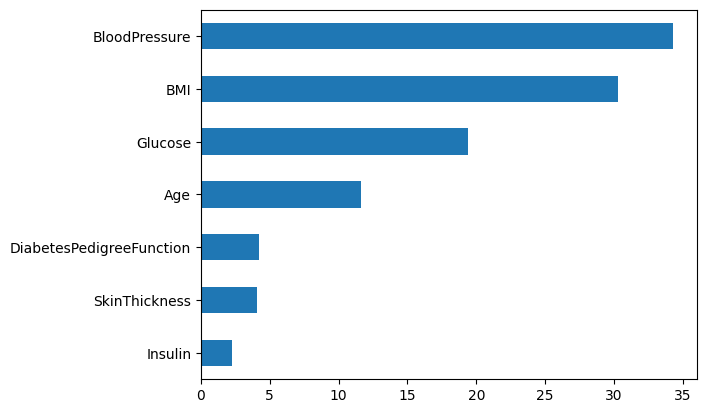

In [37]:
vif_list =  [round(variance_inflation_factor(x.values, i), 3)  for i in range(x.shape[1])]

s1 = pd.Series(vif_list, index=x.columns)
s1.sort_values().plot(kind='barh')

<Axes: >

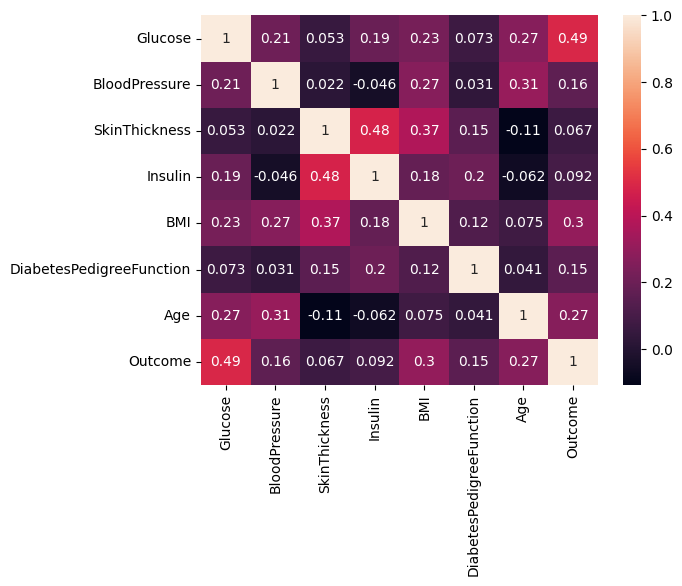

In [38]:
sns.heatmap(df_diab.corr(), annot=True)

### 6. Model Building

#### 6.1 Train Test Split

In [39]:
x = df_diab.drop('Outcome', axis = 1)
y = df_diab['Outcome']

In [40]:
y.value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [42]:
y.value_counts(normalize=True)

Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64

In [46]:
x_train ,x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=2, stratify=y)

In [47]:
y_test.value_counts(normalize=True)

Outcome
0    0.649351
1    0.350649
Name: proportion, dtype: float64

In [48]:
y_train.value_counts(normalize=True)

Outcome
0    0.651466
1    0.348534
Name: proportion, dtype: float64

### 7. Model Instantiation

In [49]:
log_clf = LogisticRegression()
log_clf.fit(x_train, y_train)

LogisticRegression()

In [50]:
log_clf.coef_

array([[ 3.61056701e-02, -3.41348469e-03, -1.31644851e-03,
        -8.15287302e-04,  9.93166640e-02,  9.63554310e-01,
         3.89707038e-02]])

### 8 Evaluation

In [51]:
def evaluation(string,model, ind_var, act):
    print(string.center(50,'*'))
    pred = model.predict(ind_var)

    acc_score = accuracy_score(act, pred)
    print('Accuracy Score :', acc_score)
    print('**'*20)

    cnf_matrix = confusion_matrix(act, pred)
    print('Confusion Matrix :\n', cnf_matrix)
    print('**'*20)

    clf_report = classification_report(act, pred)
    print('Classification Report :\n', clf_report)
    print('**'*20)

    return pred

y_pred_test = evaluation('Test Data Evaluation', log_clf, x_test, y_test)

***************Test Data Evaluation***************
Accuracy Score : 0.7597402597402597
****************************************
Confusion Matrix :
 [[90 10]
 [27 27]]
****************************************
Classification Report :
               precision    recall  f1-score   support

           0       0.77      0.90      0.83       100
           1       0.73      0.50      0.59        54

    accuracy                           0.76       154
   macro avg       0.75      0.70      0.71       154
weighted avg       0.76      0.76      0.75       154

****************************************


In [ ]:
0 >> neg
1 >> pos

TN FP
FN TP  

    0    1
0   90   10
1   27   27

acc = (90+27)/154
acc

In [52]:
precision = 27/(27+10)         # Precision for class 1
round(precision,2)

0.73

In [53]:
precision = 90/(90+27)         # Precision for class 0
round(precision,2)

0.77

In [78]:
recall = 27/(27+27)         # Recall for class 1
round(recall,2)

0.5

In [79]:
recall = 90/(90+10)         # Recall for class 0
round(recall,2)

0.9

In [82]:
f1 = (2 * 0.73 * 0.5)/(0.73 + 0.5)   # f1 for class 1
round(f1,2)

0.59

In [83]:
f1 = (2 * 0.77 * 0.9)/(0.77 + 0.9)   # f1 for class 0
round(f1,2)

0.83

In [54]:
y_pred_train = evaluation('Train Data Evaluation', log_clf, x_train, y_train)

**************Train Data Evaluation***************
Accuracy Score : 0.7785016286644951
****************************************
Confusion Matrix :
 [[349  51]
 [ 85 129]]
****************************************
Classification Report :
               precision    recall  f1-score   support

           0       0.80      0.87      0.84       400
           1       0.72      0.60      0.65       214

    accuracy                           0.78       614
   macro avg       0.76      0.74      0.75       614
weighted avg       0.77      0.78      0.77       614

****************************************


### 9. Macro avg

In [ ]:
Macro avg >> Treats every class equally

Balanced data

if working with balance data >> all the classes are treated equally

Calculates arithmatic mean(simple mean)
It uses f1 scores

In [87]:
(0.8 + 0.72)/2 , (0.87 + 0.6)/2, (0.84 + 0.65)/2

(0.76, 0.735, 0.745)

### 10. Weighted avg

In [ ]:
Weighted avg >> Imbalance data

if working with imbalance data >> where classes needs to be given more weights

In [ ]:
      f1    support     support proportion  weighted avg
0    0.84     400             0.65
1    0.65     214             0.35          (0.84*0.65) + (0.65 * 0.35)

In [89]:
400/(400+214) , 214/(400+214)

(0.6514657980456026, 0.3485342019543974)

In [90]:
(0.84*0.65) + (0.65 * 0.35)

0.7735000000000001

<Axes: >

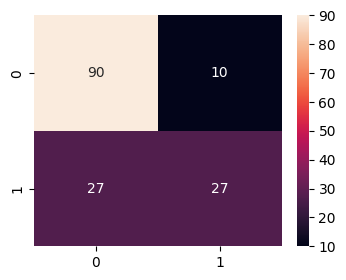

In [55]:
plt.figure(figsize=(4,3))
cnf_matrix = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cnf_matrix, annot=True)

### AUC ROC Curve

In [56]:
y_pred_proba = log_clf.predict_proba(x_test)
y_pred_proba

array([[0.92187938, 0.07812062],
       [0.93900593, 0.06099407],
       [0.21963774, 0.78036226],
       [0.31814737, 0.68185263],
       [0.88851064, 0.11148936],
       [0.88024071, 0.11975929],
       [0.88467073, 0.11532927],
       [0.32421892, 0.67578108],
       [0.77812341, 0.22187659],
       [0.55785673, 0.44214327],
       [0.02153363, 0.97846637],
       [0.58318214, 0.41681786],
       [0.67479885, 0.32520115],
       [0.31934664, 0.68065336],
       [0.4482599 , 0.5517401 ],
       [0.16353814, 0.83646186],
       [0.89782147, 0.10217853],
       [0.85813468, 0.14186532],
       [0.930319  , 0.069681  ],
       [0.73111783, 0.26888217],
       [0.50155691, 0.49844309],
       [0.84114103, 0.15885897],
       [0.426877  , 0.573123  ],
       [0.32505722, 0.67494278],
       [0.98328015, 0.01671985],
       [0.73998812, 0.26001188],
       [0.52676884, 0.47323116],
       [0.18226647, 0.81773353],
       [0.53992793, 0.46007207],
       [0.31870745, 0.68129255],
       [0.

In [57]:
y_pred_test[:5]

array([0, 0, 1, 1, 0], dtype=int64)

In [ ]:
thresh = 0.5
            0            1
       [0.92187834, 0.07812166],     >> Class 0
       [0.93900471, 0.06099529],     >> Class 0
       [0.21963892, 0.78036108],     >> Class 1
       [0.31814918, 0.68185082],
       [0.8885094 , 0.1114906 ],
       [0.88023947, 0.11976053],
       [0.88466989, 0.11533011],
       [0.32421937, 0.67578063],
       [0.77812255, 0.22187745],
       [0.55785713, 0.44214287],
       [0.02153419, 0.97846581],

In [ ]:
thresh = 0.6
            0           1
       [0.94369996, 0.05630004],      >> Class 0
       [0.43593155, 0.56406845],      >> Class 0
       [0.77784877, 0.22215123],
       [0.7042203 , 0.2957797 ],
       [0.32802709, 0.67197291],      >> Class 1
       [0.71686279, 0.28313721],
       [0.64367357, 0.35632643],
       [0.5423636 , 0.4576364 ],

In [58]:
y_pred_proba[:, 1]

array([0.07812062, 0.06099407, 0.78036226, 0.68185263, 0.11148936,
       0.11975929, 0.11532927, 0.67578108, 0.22187659, 0.44214327,
       0.97846637, 0.41681786, 0.32520115, 0.68065336, 0.5517401 ,
       0.83646186, 0.10217853, 0.14186532, 0.069681  , 0.26888217,
       0.49844309, 0.15885897, 0.573123  , 0.67494278, 0.01671985,
       0.26001188, 0.47323116, 0.81773353, 0.46007207, 0.68129255,
       0.3148301 , 0.16422853, 0.09301107, 0.77277633, 0.23919233,
       0.33843017, 0.04526265, 0.16285583, 0.05424116, 0.05629905,
       0.56406867, 0.22214986, 0.29577854, 0.67197441, 0.28313737,
       0.3563262 , 0.45763774, 0.20287596, 0.01737588, 0.20776037,
       0.29159619, 0.13651065, 0.62713728, 0.1018891 , 0.75133075,
       0.36057636, 0.07493849, 0.04038527, 0.37569193, 0.07172967,
       0.17168412, 0.08920902, 0.22541258, 0.23724594, 0.61172222,
       0.40503293, 0.20348473, 0.64484166, 0.63427402, 0.08055408,
       0.66053162, 0.22829683, 0.69739044, 0.08439605, 0.89443

In [59]:
fpr , tpr, thresh = roc_curve(y_test, y_pred_proba[:, 1])
fpr

array([0.  , 0.  , 0.  , 0.01, 0.01, 0.03, 0.03, 0.04, 0.04, 0.05, 0.05,
       0.07, 0.07, 0.09, 0.09, 0.1 , 0.1 , 0.12, 0.12, 0.17, 0.17, 0.18,
       0.18, 0.21, 0.21, 0.22, 0.22, 0.23, 0.23, 0.24, 0.24, 0.27, 0.27,
       0.29, 0.29, 0.3 , 0.3 , 0.37, 0.37, 0.39, 0.39, 0.44, 0.44, 0.46,
       0.46, 0.48, 0.48, 0.49, 0.49, 0.53, 0.53, 0.54, 0.54, 0.56, 0.56,
       0.62, 0.62, 1.  ])

In [60]:
tpr

array([0.        , 0.01851852, 0.03703704, 0.03703704, 0.14814815,
       0.14814815, 0.18518519, 0.18518519, 0.24074074, 0.24074074,
       0.25925926, 0.25925926, 0.37037037, 0.37037037, 0.48148148,
       0.48148148, 0.5       , 0.5       , 0.53703704, 0.53703704,
       0.55555556, 0.55555556, 0.59259259, 0.59259259, 0.61111111,
       0.61111111, 0.62962963, 0.62962963, 0.66666667, 0.66666667,
       0.68518519, 0.68518519, 0.7037037 , 0.7037037 , 0.74074074,
       0.74074074, 0.75925926, 0.75925926, 0.7962963 , 0.7962963 ,
       0.81481481, 0.81481481, 0.85185185, 0.85185185, 0.87037037,
       0.87037037, 0.90740741, 0.90740741, 0.92592593, 0.92592593,
       0.94444444, 0.94444444, 0.96296296, 0.96296296, 0.98148148,
       0.98148148, 1.        , 1.        ])

In [61]:
thresh

array([       inf, 0.97846637, 0.94008325, 0.93005734, 0.81773353,
       0.78036226, 0.77277633, 0.77274156, 0.71424542, 0.69739044,
       0.68185263, 0.68065336, 0.64484166, 0.62713728, 0.56406867,
       0.5517401 , 0.50342943, 0.47928468, 0.47323116, 0.44520971,
       0.44214327, 0.41681786, 0.40503293, 0.39340488, 0.37569193,
       0.36057636, 0.3563262 , 0.34253869, 0.32520115, 0.31935655,
       0.31901687, 0.29577854, 0.29420693, 0.28313737, 0.26888217,
       0.26675518, 0.2644237 , 0.22829683, 0.22286274, 0.22187659,
       0.20969134, 0.20287596, 0.19680018, 0.18394632, 0.17992975,
       0.1732223 , 0.16451693, 0.16422853, 0.16352459, 0.1525716 ,
       0.14903658, 0.14186532, 0.14113361, 0.13651065, 0.13030596,
       0.11148936, 0.10806193, 0.0126798 ])

### ROC Curve

Text(0, 0.5, 'True Positve Rate')

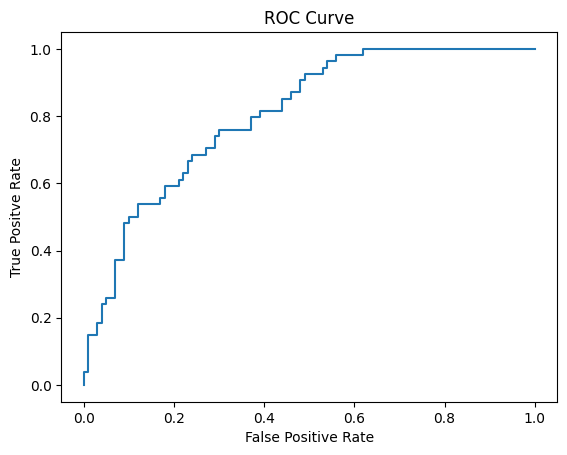

In [63]:
plt.title('ROC Curve')
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positve Rate')

In [64]:
auc_score = roc_auc_score(y_test, y_pred_proba[:, 1])
auc_score

0.8042592592592592

In [65]:
# Prob to belonging to class 1

value_pred = []

for i in y_pred_proba[:,1]:
    if i>=0.6:
        value_pred.append(1)
    else:
        value_pred.append(0)

In [66]:
arr = np.array(value_pred)

confusion_matrix(y_test, arr)

array([[91,  9],
       [32, 22]], dtype=int64)

In [67]:
print(classification_report(y_test, arr))

              precision    recall  f1-score   support

           0       0.74      0.91      0.82       100
           1       0.71      0.41      0.52        54

    accuracy                           0.73       154
   macro avg       0.72      0.66      0.67       154
weighted avg       0.73      0.73      0.71       154



In [109]:
y_pred_proba[22:23]

array([[0.42687802, 0.57312198]])

In [111]:
result = y_pred_proba[22:23]
result[0,1]

0.5731219812493673

In [114]:
def get_pred_class(threshold, result):
    prob = result[0,1]
    if prob >= threshold:
        return 'Class1'

    else:
        return 'Class0'

result = y_pred_proba[22:23]
threshold = 0.5
pred_class = get_pred_class(threshold, result)
print('Predicted Class is:', pred_class)

Predicted Class is: Class1


In [115]:
def get_pred_class(threshold, result):
    prob = result[0,1]
    if prob >= threshold:
        return 'Class1'

    else:
        return 'Class0'

result = y_pred_proba[22:23]
threshold = 0.6
pred_class = get_pred_class(threshold, result)
print('Predicted Class is:', pred_class)

Predicted Class is: Class0


### Test Model on Single row

In [117]:
x.head(1).T

,0
Glucose,148.000
BloodPressure,50.000
SkinThickness,35.000
Insulin,0.000
BMI,33.600
DiabetesPedigreeFunction,0.627
Age,50.000


In [123]:
Glucose= 114.000
BloodPressure=45.000
SkinThickness=30.000
Insulin=0.2
BMI=24.00
DiabetesPedigreeFunction=0.4
Age=30.000

test_array = np.array([Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age], ndmin =2)
# test_array
pred_class = log_clf.predict(test_array)[0]
print('Predicted Class is:', pred_class)   # Threshold 0.5

Predicted Class is: 0


In [124]:
Glucose= 114.000
BloodPressure=45.000
SkinThickness=30.000
Insulin=0.2
BMI=24.00
DiabetesPedigreeFunction=0.4
Age=30.000

test_array = np.array([Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age], ndmin =2)
# test_array
# pred_class = log_clf.predict(test_array)[0]
# print('Predicted Class is:', pred_class

def get_pred_class(threshold, result):
    prob = result[0,1]
    if prob >= threshold:
        return 'Class1'

    else:
        return 'Class0'

result = log_clf.predict_proba(test_array)
print(result)
threshold = 0.6
pred_class = get_pred_class(threshold, result)
print('Predicted Class is:', pred_class)

[[0.88107814 0.11892186]]
Predicted Class is: Class0


In [125]:
Glucose= 149.000
BloodPressure=54.000
SkinThickness=39.000
Insulin=0.2
BMI=35.00
DiabetesPedigreeFunction=0.7
Age=53.000

test_array = np.array([Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age], ndmin =2)
# test_array
# pred_class = log_clf.predict(test_array)[0]
# print('Predicted Class is:', pred_class

def get_pred_class(threshold, result):
    prob = result[0,1]
    if prob >= threshold:
        return 'Class1'

    else:
        return 'Class0'

result = log_clf.predict_proba(test_array)
print(result)
threshold = 0.6
pred_class = get_pred_class(threshold, result)
print('Predicted Class is:', pred_class)

[[0.1829773 0.8170227]]
Predicted Class is: Class1
